# $(SA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\alpha^2 + \beta^2 + \gamma^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *

import gymnasium as gym
import rlenvs

In [2]:
output = torch.Tensor([[1.5,2.5], [3.5, 4.5]])
y = torch.Tensor([[1.,2.], [3., 4.]])

torch.nn.functional.mse_loss(output, y)

tensor(0.2500)

In [3]:
n_episodes = 100

# env = gym.make("custom/DiscreteCartPole-v1")
env = gym.make("custom/CartPole-v1")

data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
# for i in data:
#     print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [4]:
def build_data2(data, dimensions=None):
    dataset = pd.DataFrame(data, columns=['s0', 's1', 'a', 'r', 'p0', 'p1', 's_0', 's_1'])
    # step = dataset.loc[:-1]
    step = dataset.loc[:dataset.shape[0]-2].reset_index()
    nextStep = dataset.loc[1:].reset_index()
    input_all = step
    input_all[['a_', 's__0', 's__1', 'r_']] = nextStep[['a', 's_0', 's_1', 'r']]
    return input_all[[
        's0','s1','a','s_0','s_1','a_',
        's__0', 's__1', 'r_',
        'p0', 'p1'
    ]].values


# Estimador 

In [5]:
class TransitionEstimatorBaseS3(nn.Module):
    def __init__(self, s,a, hidden_size, output):
        super(TransitionEstimatorBaseS3, self).__init__()
        self.input_set = sum([s,a,s,a, s,a,s, s,a,s])

        self.l1 = nn.Linear(self.input_set, hidden_size)
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()

    def forward(self, x, mode='all'):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        out = self.than(out)
        out = self.l3(out)
        return out
    
class TransitionEstimatorS3(nn.Module):
    def __init__(self, s,a,p, hidden_size, output):
        super(TransitionEstimatorS3, self).__init__()
        self._s = s
        self._a = a
        self._p = p

        self.input_param = sum([s,a,s])
        # self.input_param_ = sum([s,a,s])
        self.input_state = sum([s,a,p])
        # self.input_state_ = sum([s,a,p])
        
        self.par1 = nn.Linear(self.input_param, hidden_size)
        self.par2 = nn.Linear(hidden_size, p)
        self.s1 = nn.Linear(self.input_state, hidden_size)
        self.s2 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()


    def forward_param(self, x):
        """
            x: Input data of format (s, a, s') for estimating only the parameters (p)
        """
        out = self.par1(x)
        out = self.relu(out)
        out = self.par2(out)

        return out
    
    def forward_state(self, x):
        """
            x: Input data of format (s', a', p) for estimating only the state (s'')
        """
        out = self.s1(x)
        out = self.than(out)
        out = self.s2(out)

        return out

    def forward(self, x):
        """
            x: Input data (s,a,s_,a_, s,a,s, s,a,s)
        """
        in_shape = (self._s*2 + self._a*2 + (self._s*2 + self._a)*2)
        assert x.shape[1] == in_shape, f"Invalid input format ({x.shape[1]}) expected ({in_shape})"
        
        p_anchor_idx = self._s + self._a + self._s
        s_anchor_idx = self._s + self._a
        
        pInput = x[:, :p_anchor_idx]
        p = self.forward_param(pInput)
        s_Input = torch.concat([x[:, s_anchor_idx : s_anchor_idx*2], p], axis=1)
        s_ = self.forward_state(s_Input)

        pReff_idx = s_anchor_idx*2 + self._s + self._a + self._s
        
        pReff_Input = x[:, s_anchor_idx*2 : pReff_idx]
        p_Reff = self.forward_param(pReff_Input)
        
        pReff2_Input = x[:, pReff_idx:]
        p_Reff2 = self.forward_state(pReff2_Input)

        self.p = p
        self.s_ = s_
        self.p_Reff = p_Reff
        self.p_Reff2 = p_Reff2

        return torch.concat([s_, p, p_Reff, p_Reff2,  # estimatives for s__, p, pReff and pReff2
                             x[:, :self._s], x[:, pReff_idx:pReff_idx+self._s], # s and sReff from the inputs
                             x[:, s_anchor_idx:s_anchor_idx+self._s], x[:,pReff_idx+self._s+self._a:], # s_ and s_Reff from the inputs
                            ], axis=1)


class MyLoss(nn.MSELoss):
    def forward(self, output, target):
        p = self._Model__estimator._p
        s = self._Model__estimator._s

        alpha = 1
        beta = 1
        gamma = 1
        lambda_ = 0.001

        mse_s_ = super().forward(output[:,:s], target)
        mse_p_reff = super().forward(output[:,s:s+p], output[:,s+p:s+p*2])
        mse_p_reff_dff = super().forward(output[:,s:s+p], output[:,s+p*2:s+p*3])

        loss = torch.mean(alpha*mse_p_reff + beta*(1-mse_p_reff_dff) + gamma*mse_s_ + lambda_*(alpha**2 + beta**2 + gamma**2))
        return loss


# Modelo

In [6]:
class Model2():
    def __init__(self,
                input_size = (2, 1, 2), # 2d for s and s_, 1d for a and a_, and 2d for p,
                hidden_size = 10,
                output = 2, #2d for s_
                learning_rate = [0.001, 0.001],
                estimators_clss = [TransitionEstimator, RewardEstimatorBase],
                criterion_clss = [nn.MSELoss, nn.BCELoss],
                optimizer_clss = [optim.Adam, optim.Adam],
            ) -> None:
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output = output
        self.learning_rate = learning_rate

        self.estimatorT = estimators_clss[0](*input_size, hidden_size, output)
        self.estimatorR = estimators_clss[1](input_size[0],input_size[1], hidden_size)
        
        self.criterionT = criterion_clss[0]()
        self.criterionR = criterion_clss[1]()
        self.optimizerT = optimizer_clss[0](self.estimatorT.parameters(), lr=learning_rate[0])
        self.optimizerR = optimizer_clss[1](self.estimatorR.parameters(), lr=learning_rate[1])

        self.criterionT._Model__estimator = self.estimatorT

        self.train_dataset = None

    def getReffs(self, dataset):
        def getReff(p):
            eq_reff_cond = (self.train_dataset['p0'] == p['p0']) & (self.train_dataset['p1'] == p['p1'])
            filtered = self.train_dataset[eq_reff_cond].reset_index()
            index = np.random.choice(filtered.shape[0], 1,replace=False)  
            eq_reff = filtered.loc[index]
            return pd.Series(eq_reff[['s0','s1','a','s_0','s_1', 'p0', 'p1']].values[0], index=['s0Reff','s1Reff','aReff','s_0Reff','s_1Reff', 'p0Reff', 'p1Reff'])

        def getReffDiff(p):
            eq_reff_cond = (self.train_dataset['p0'] != p['p0']) & (self.train_dataset['p1'] != p['p1'])
            filtered = self.train_dataset[eq_reff_cond].reset_index()
            index = np.random.choice(filtered.shape[0], 1,replace=False)  
            eq_reff = filtered.loc[index]
            return pd.Series(eq_reff[['s0','s1','a','s_0','s_1', 'p0', 'p1']].values[0], index=['s0ReffDiff','s1ReffDiff','aReffDiff','s_0ReffDiff','s_1ReffDiff', 'p0ReffDiff', 'p1ReffDiff'])

        def reverse_transform_row(row):
            return pd.Series({
                's0': row['s'][0],
                's1': row['s'][1],
                'a': row['a'],
                's_0': row['s_'][0],
                's_1': row['s_'][1],
                'a_': row['a_'],
                'p0': row['p'][0],
                'p1': row['p'][1],
                'r_': row['r_'],
                's__0': row['s__'][0],
                's__1': row['s__'][1]
            })
        
        # df = dataset.apply(reverse_transform_row, axis=1)
        df = dataset

        # df = pd.DataFrame(dataset, columns=['s0', 's1', 'a', 'r', 'p0', 'p1', 's_0', 's_1'])
        df[['s0Reff','s1Reff','aReff','s_0Reff','s_1Reff', 'p0Reff', 'p1Reff']] =  df.apply(getReff, axis=1, result_type='expand')
        df[['s0ReffDiff','s1ReffDiff','aReffDiff','s_0ReffDiff','s_1ReffDiff', 'p0ReffDiff', 'p1ReffDiff']] =  df.apply(getReffDiff, axis=1, result_type='expand')
        return df.reset_index()

    def store_dataset(self, dataset):
        df = pd.DataFrame(dataset, columns=[
            's0','s1','a','s_0','s_1','a_',
            's__0', 's__1', 'r_',
            'p0', 'p1'
        ])
        def transform_row(row):
            return pd.Series({
                's': row[['s0', 's1']].tolist(),
                'a': row['a'], 
                'p': row[['p0', 'p1']].tolist(),
                's_': row[['s_0', 's_1']].tolist(),
                'a_': row['a_'],
                'r_': row['r_'],
                's__': row[['s__0', 's__1']].tolist()
            })

        # df_transformed = df.apply(transform_row, axis=1)
        if self.train_dataset is None:
            self.train_dataset = df
        else: 
            self.train_dataset = pd.concat([self.train_dataset, df]).reset_index().drop(columns=['index'])
        return df

    def train_data(self, data, random=True, dimensions=None):
        dimensions = dimensions if dimensions is not None else {
            's': 2, 'a':1, 'r': 1, 'p':2
        }

        if random:
            n = data.shape[0]
            index = np.random.choice(n, n, replace=False)  
        else:
            index = np.arange(n)

        dataset = data.iloc[index]
        # dataset = data.values[index]

        # input_index = dimensions['s']*2 + dimensions['a']*2 + (dimensions['s']*2 + dimensions['a'])*2
        # input_all = dataset[:,:input_index]
        # output_all = dataset[:, input_index:]

        X = torch.tensor(dataset[['s0','s1','a','s_0','s_1','a_', 
                                  's0Reff','s1Reff','aReff','s_0Reff','s_1Reff', 
                                  's0ReffDiff','s1ReffDiff','aReffDiff','s_0ReffDiff','s_1ReffDiff'
                                ]].values, dtype=torch.float32)
        y = torch.tensor(dataset[['s__0','s__1','r_', 
                                  'p0','p1', 'p0Reff','p1Reff', 'p0ReffDiff','p1ReffDiff'
                                  ]].values, dtype=torch.float32)
        return X,y

    def train(self, dataset, num_epochs=100, debug=False, mode='all'):
    # def train(self, X_train, y_train, num_epochs=100, debug=False, mode='all'):
        # Training loop
        data = self.store_dataset(dataset)
        prepared_data = self.getReffs(data)
        X, y = self.train_data(prepared_data)
        X_train, y_train = X, y[:, :-6]
        
        for epoch in range(num_epochs):
            # Training Transition Estimator
            index = np.random.choice(X_train.shape[0], X_train.shape[0], replace=False)  

            self.optimizerT.zero_grad()
            outputs = self.estimatorT(X_train[index])
            
            loss = self.criterionT(outputs, y_train[:,:-1][index])
            loss.backward()

            torch.nn.utils.clip_grad_norm_(self.estimatorT.parameters(), max_norm=1.0) 
            self.optimizerT.step()  

            if debug and (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Transition Loss: {loss.item():.4f}')  

            # Training Reward Estimator
            if mode == 'all':
                self.optimizerR.zero_grad()
                outputs = self.estimatorR(X_train[index][:,-3:-1])
                # outputs = self.estimatorR(X_train[:,3:-1])
                # loss = self.criterionR(outputs.squeeze(), y_train[:,-1])
                loss = self.criterionR(outputs.squeeze(), y_train[:,-1][index])

                loss.backward()
                self.optimizerR.step()  

                if debug and (epoch+1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{num_epochs}], Reward Loss: {loss.item():.4f}')  
            else:
                print(f'Trainning Reward model is not implemented for {mode} mode')
        return X,y

    def sample(self, dataset, mode='all'):
        """
            x: Input data, its format depends on the mode. It can be (s,a,s',a'), (s,a,s'), or (s',a',p)
            mode: one of the oprions:
                'all' - (Default) Uses the set of inputs (s, a, s', a') for estimating the parameters and using it to estimate the state (s'')
                'param' - Uses the set of inputs (s, a, s') for estimating only the parameters (p)
                'state' - Uses the set of inputs (s', a', p) for estimating only the state (s'')
        """
        data = self.store_dataset(dataset)
        prepared_data = self.getReffs(data)
        x, _ = self.train_data(prepared_data)
        s,r = None, None
        with torch.no_grad():
            s = self.estimatorT(x)
            # r = self.estimatorR(x[:,:self.input_size[0]])
            r = self.estimatorR(s[:,:2])

        out = s 
        return out, r

In [7]:
n_agents = 1

pmbrl = [Model2(
        estimators_clss=[TransitionEstimatorS3, RewardEstimatorBase], 
        criterion_clss=[MyLoss, nn.BCELoss], 
        learning_rate=[0.0001,0.001]
    ) for _ in range(n_agents)]
# mbrl = [ModelBase(
#         normalizer_clss=Normalizer2, 
#         estimators_clss=[TransitionEstimatorBaseS3, RewardEstimatorBase], 
#         learning_rate=[0.0001,0.001]
#     ) for _ in range(n_agents)]

# Experimento

In [8]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, val=200, verbose=False):
    results = []
        # X, y = train_data2(build_data2(dataset))
    dataset = build_data2(np.concat(data, axis=0))
    
    for j, agent in enumerate(models):
        if verbose:
            print(f'Agent {j}...')
        agent.train(dataset[:-val], **training)
        # agent.train(X[:-val], y[:-val, :-6], **training)
        s,r = agent.sample(dataset[-val:], mode=training['mode'])
        results.append(torch.concat([
                torch.tensor([j]*val).unsqueeze(1),
                torch.nn.functional.mse_loss(s[:,:2], torch.tensor(dataset[-val:,-5:-3]), reduction='none').mean(dim=0).repeat(val, 1),
                torch.nn.functional.mse_loss(r, torch.tensor(dataset[-val:,-3:-2]), reduction='none').mean().repeat(val, 1),
                # (torch.mean((s[:,:2] - dataset[-val:,-5:-3])**2, axis=0)**.5).repeat(val, 1),
                # (torch.mean((r - dataset[-val:,-3])**2, axis=0)**.5).unsqueeze(1),
                s[:,2:4],
                s[:,4:6],
                s[:,6:8],
                torch.tensor(dataset[-val:, -2:])
            ], axis=1))
    
    d = np.array(results).reshape(len(results)*val, results[0].shape[1])
    return pd.DataFrame(d, columns=['agent', 's_0', 's_1', 'r', 'p0', 'p1', 'pReff0', 'pReff1','pReff20', 'pReff21', 'reff_p0', 'reff_p1']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

# Treino

In [9]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
# pmbrl_plot = pmbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

Training pmbrl...
Agent 0...
pmbrl done!


In [10]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# # mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
# mbrl_plot = mbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

In [11]:
pmbrl_results

,agent,s_0,s_1,r,p0,p1,pReff0,pReff1,pReff20,pReff21,reff_p0,reff_p1
0,0.0,0.106487,2.247535,0.036096,-0.271756,0.981172,-0.641380,1.893834,0.106378,0.244255,0.74,0.6
1,0.0,0.106487,2.247535,0.036096,-0.262879,0.588076,-0.358909,0.851246,-0.242348,0.869324,0.74,0.6
2,0.0,0.106487,2.247535,0.036096,-0.327457,0.704865,-0.268221,0.435522,0.492741,-0.402036,0.74,0.6
3,0.0,0.106487,2.247535,0.036096,-0.461428,1.298010,-0.358099,0.956912,0.461010,-0.406836,0.74,0.6
4,0.0,0.106487,2.247535,0.036096,-0.274047,0.534034,-0.282889,0.632554,0.826861,-0.859202,0.74,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.0,0.106487,2.247535,0.036096,-0.284541,0.580317,-0.257754,0.653730,0.482768,-0.312951,0.64,0.0
196,0.0,0.106487,2.247535,0.036096,-0.380736,1.287007,-0.518242,1.380136,1.088906,-1.193854,0.64,0.0
197,0.0,0.106487,2.247535,0.036096,-0.345936,0.834639,-0.274381,0.540016,0.592298,-0.513143,0.64,0.0
198,0.0,0.106487,2.247535,0.036096,-0.211004,0.508248,-0.328670,0.369229,0.403128,-0.133775,0.64,0.0


In [ ]:
def add_plot(name, d, axis, reffs):
    # reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(d['p0'], color = 'g')
    axis[0].plot(reffs[0], linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5) - 2)

    axis[1].plot(d['p1'], color = 'b')
    axis[1].plot(reffs[1], linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5) - 2)

    fig, axs = plt.subplots(1, 2, figsize=(16, 4))





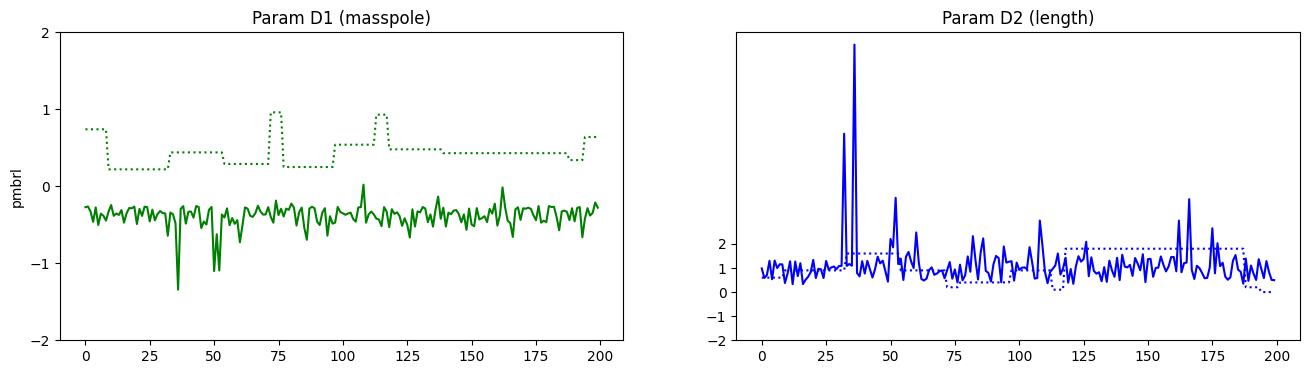

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].set_title('Param D1 (masspole)')
axs[1].set_title('Param D2 (length)')

add_plot(f'pmbrl', pmbrl_results, axs, (pmbrl_results.reff_p0, pmbrl_results.reff_p1))

plt.show()

# Teste

In [14]:
# for epi in data:
#     print(epi[0])

In [15]:
# for epi in data:
#     print(epi[1])

In [16]:
n_episodes = 10

env = gym.make("custom/CartPole-v1")
data = [generate_episode(env=env) for _ in range(n_episodes)]
# data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
for i in data:
    print(i.shape)

(71, 8)
(23, 8)
(24, 8)
(38, 8)
(17, 8)
(15, 8)
(38, 8)
(17, 8)
(38, 8)
(20, 8)


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [17]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        # X, y = build_train_data(epi)
        # dataset = build_data2(epi)
        dataset = build_data2(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, step in enumerate(dataset):
                features = np.expand_dims(step, axis=0)
                target = features[:,6:9]
                s,r = agent.sample(features, mode=training['mode'])
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        # torch.nn.functional.mse_loss(s[:,:2],target[:,:2]),
                        # torch.nn.functional.mse_loss(r,target[:,2:3]),
                        torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
                        torch.mean((r - target[:,2:3])**2, axis=0)**.5,
                        s[0,2:4],
                        s[0,4:6],
                        s[0,6:8],
                        torch.tensor(features[0, -2:])
                    ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r', 'p0', 'p1', 'pReff0', 'pReff1','pReff20', 'pReff21', 'reff_p0', 'reff_p1']) 


In [18]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

Training pmbrl...
Episode 0...
Agent 0...


/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context a

Episode 1...
Agent 0...


/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context a

Episode 2...
Agent 0...


...

/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context a

Episode 7...
Agent 0...
Episode 8...
Agent 0...


/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context a

Episode 9...
Agent 0...
pmbrl done!


/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((s[:,:2] - target[:,:2])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.mean((r - target[:,2:3])**2, axis=0)**.5,
/tmp/ipykernel_5371/1434522944.py:21: DeprecationWarning: __array_wrap__ must accept context a

In [19]:
# print('Training mbrl...')
# mbrl_results = run(data, mbrl, verbose=True)
# print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

In [20]:
pmbrl_results

,epi,agent,step,s_0,s_1,r,p0,p1,pReff0,pReff1,pReff20,pReff21,reff_p0,reff_p1
0,0.0,0.0,0.0,0.156094,0.261761,0.140943,-0.281280,0.820391,-0.281280,0.820391,0.960821,-0.956060,0.04,1.7
1,0.0,0.0,1.0,0.115900,0.303828,0.150111,-0.301664,0.871277,-0.281280,0.820391,0.889105,-1.066062,0.04,1.7
2,0.0,0.0,2.0,0.178996,0.227407,0.138536,-0.326332,0.925626,-0.281280,0.820391,0.499322,-0.361345,0.04,1.7
3,0.0,0.0,3.0,0.110546,0.050118,0.156481,-0.431884,1.128947,-0.301664,0.871277,1.021371,-1.067048,0.04,1.7
4,0.0,0.0,4.0,0.026820,0.144324,0.170949,-0.420476,1.054766,-0.326332,0.925626,0.615820,-0.503084,0.04,1.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,9.0,0.0,14.0,0.067051,0.285015,0.183855,-0.392675,1.230006,-0.496157,1.436105,0.460153,-0.167301,0.06,1.0
287,9.0,0.0,15.0,0.270347,0.282473,0.242990,-0.515303,1.449880,-0.504658,1.459456,0.051746,0.487302,0.06,1.0
288,9.0,0.0,16.0,0.111270,0.297366,0.191230,-0.404907,1.275090,-0.504658,1.459456,0.540840,-0.487693,0.06,1.0
289,9.0,0.0,17.0,0.318052,0.293823,0.253037,-0.528133,1.498518,-0.468200,1.217826,0.515231,-0.331547,0.06,1.0


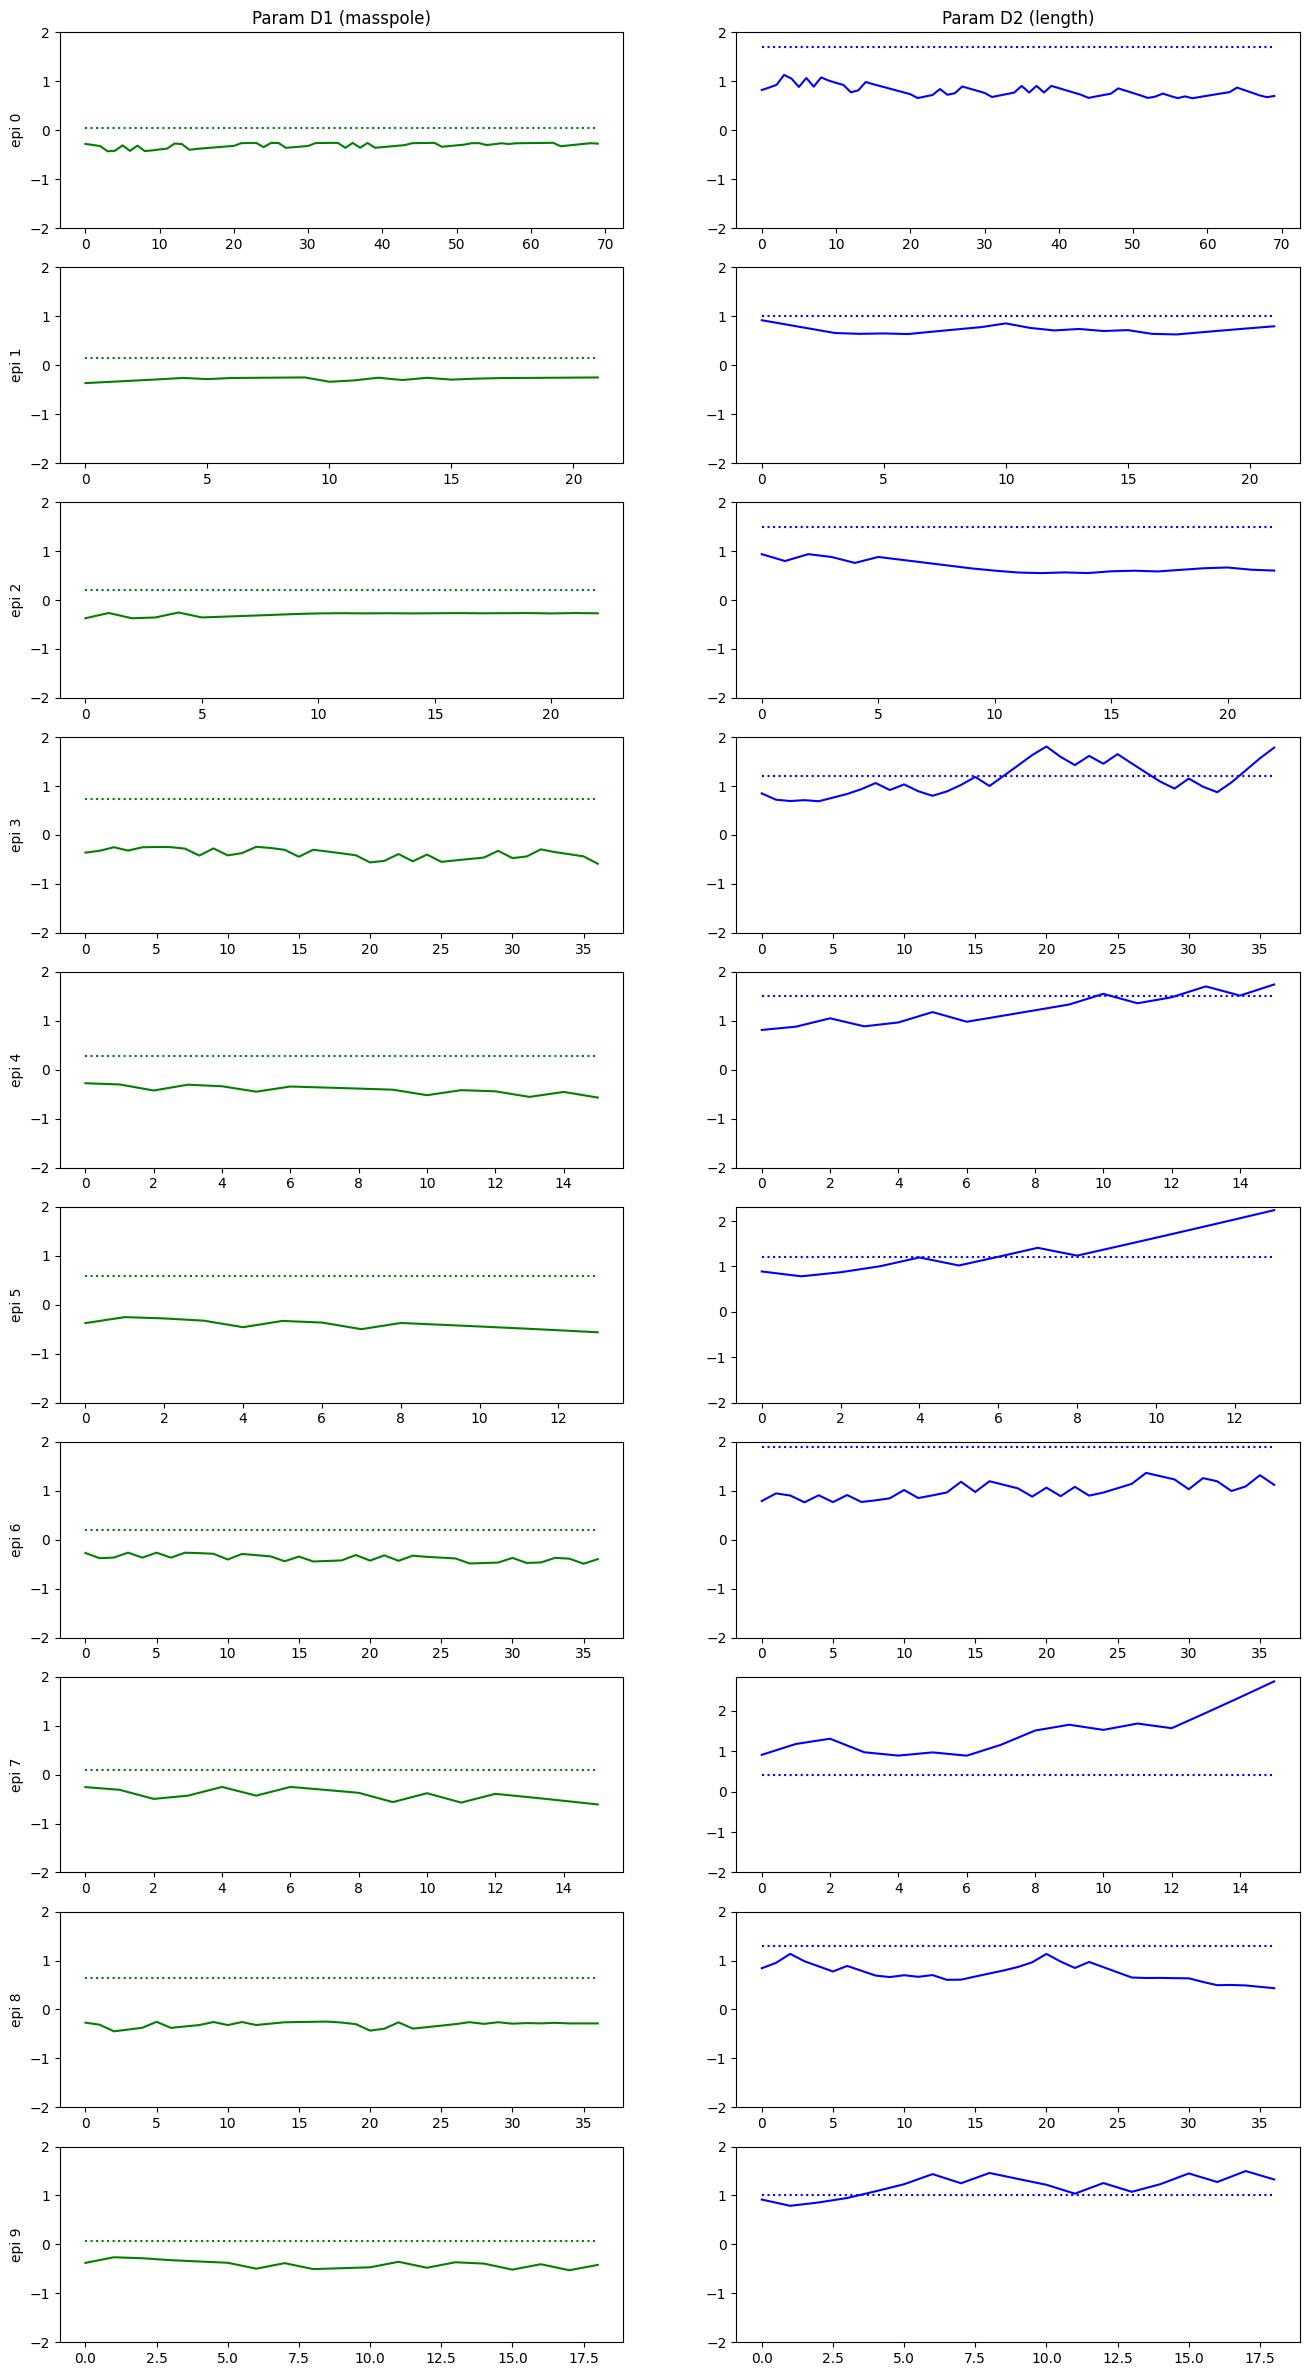

In [21]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(n, 2, figsize=(16, n*3))

axs[0][0].set_title('Param D1 (masspole)')
axs[0][1].set_title('Param D2 (length)')


for i in range(n):
    add_plot(
        f'epi {i}', 
        pmbrl_results[pmbrl_results.epi==i].reset_index(), 
        axs[i], 
        (
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p0, 
            pmbrl_results[pmbrl_results.epi==i].reset_index().reff_p1
        )
    )

plt.show()

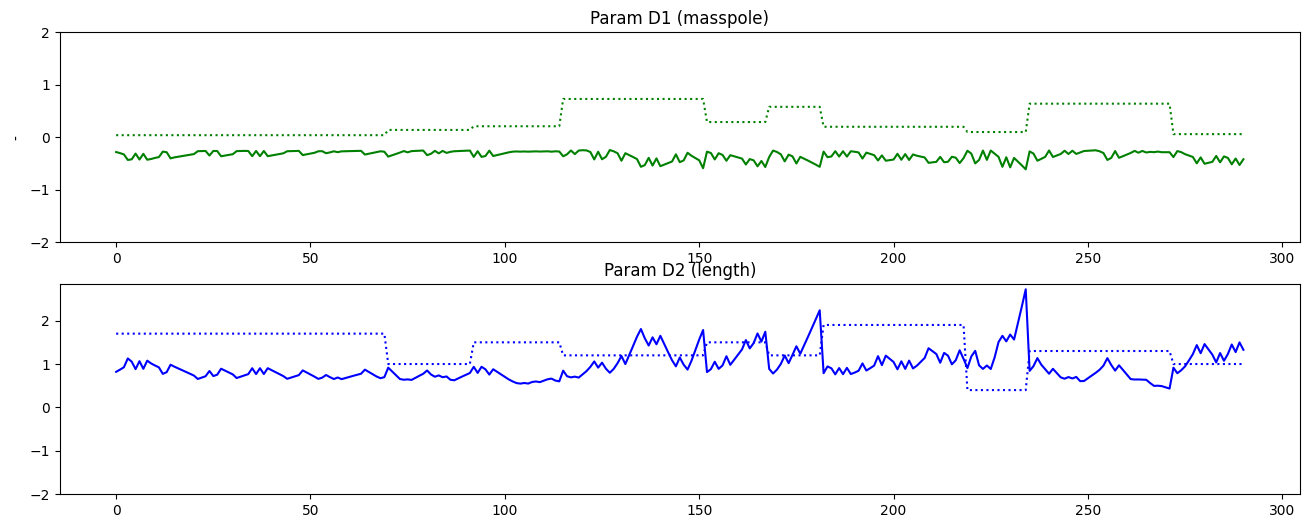

In [22]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(2, 1, figsize=(16, 6))

axs[0].set_title('Param D1 (masspole)')
axs[1].set_title('Param D2 (length)')


add_plot(
    f'-', 
    pmbrl_results.reset_index(), 
    axs, 
    (
        pmbrl_results.reset_index().reff_p0, 
        pmbrl_results.reset_index().reff_p1
    )
)

plt.show()

In [23]:
pmbrl_results[pmbrl_results.step == 0].describe()

,epi,agent,step,s_0,s_1,r,p0,p1,pReff0,pReff1,pReff20,pReff21,reff_p0,reff_p1
count,10.00000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,4.50000,0.0,0.0,0.211174,0.248319,0.136947,-0.321015,0.867775,-0.322538,0.850337,0.661368,-0.565455,0.29900,1.270000
std,3.02765,0.0,0.0,0.080591,0.183144,0.012556,0.053499,0.051143,0.052222,0.087837,0.293194,0.439453,0.25558,0.421769
min,0.00000,0.0,0.0,0.141834,0.085162,0.116099,-0.377421,0.789133,-0.377421,0.640266,0.232741,-1.407247,0.04000,0.400000
25%,2.25000,0.0,0.0,0.164207,0.101565,0.127834,-0.372122,0.825943,-0.372122,0.825943,0.473636,-0.778794,0.11000,1.050000
50%,4.50000,0.0,0.0,0.167807,0.211167,0.140512,-0.321563,0.868022,-0.325658,0.868022,0.631095,-0.571599,0.20500,1.250000
75%,6.75000,0.0,0.0,0.247185,0.313389,0.144897,-0.273055,0.913779,-0.274814,0.913779,0.806225,-0.278868,0.50750,1.500000
max,9.00000,0.0,0.0,0.359455,0.659444,0.153209,-0.256249,0.935691,-0.256249,0.935691,1.241777,0.156074,0.73000,1.900000


/tmp/ipykernel_5371/1967270628.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i])
/tmp/ipykernel_5371/1967270628.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i])
/tmp/ipykernel_5371/1967270628.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i])
/tmp/ipykernel_5371/1967270628.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
 

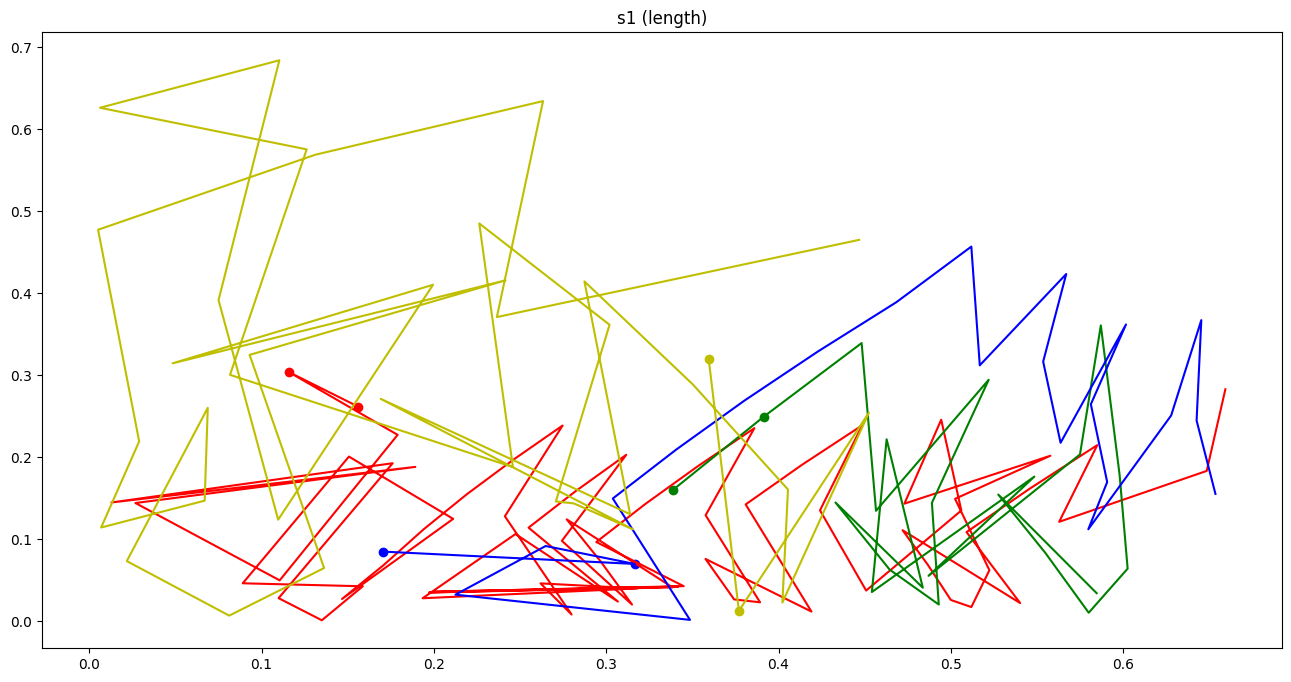

In [59]:

fig, axs = plt.subplots(1, 1, figsize=(16, 8))

axs.set_title('s0 (masspole)')
axs.set_title('s1 (length)')

colors = ['r', 'g', 'b', 'y', 'r', 'g', 'b', 'y', 'r', 'g', 'b', 'y', 'r']

for i, epi in enumerate(set(pmbrl_results['epi'].values)):
    if i <4:
        axs.plot(pmbrl_results[pmbrl_results.epi == epi][['s_0']], pmbrl_results[pmbrl_results.epi == epi][['s_1']], color = colors[i])
        axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i])
        # for a in pmbrl_results[pmbrl_results.epi == epi].a.values:
        #    if a == 1:
        #     axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.action < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i], marker='.')
        #    else: 
        #     axs.scatter(pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.action < 2][['s_0']], pmbrl_results[pmbrl_results.epi == epi][pmbrl_results.step < 2][['s_1']], color = colors[i], marker='*')
# axs[1].plot(pmbrl_results[['s_0']], color = 'g')
# axs[0].set_yticks(np.arange(5) - 2)

plt.show()